In [1]:
# Setup imports
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown as md
import time
import os
import serial
from pico import Pico

import serial.tools.list_ports
for port in serial.tools.list_ports.comports():
    print(port.device, port.description) # this should show the port where the Pi Pico

# sound feedback. use by calling beep(<number of beeps>)
beep = lambda x: os.system("echo -n '\a';sleep 0.2;" * x)

/dev/ttyACM0 Board in FS mode - Board CDC


In [2]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [3]:
pico = Pico("/dev/ttyACM0")   # replace with the actual port of the Pi Pico
print(repr(pico.exec("import Main as m"))) # loads Main.py from the Pico
print(repr(pico.exec("print(m.current_M_yaxis)"))) # Prints current M from y axis, just to test that things worked
print(pico.exec("m.enable_motor()")) # engages the motors. they should be hard to turn manually after this

✓ Uploaded Main.py → Main.py (19727 bytes)
import Main as m
'import Main as m\r\n>>> '
print(m.current_M_yaxis)
8.00625
'print(m.current_M_yaxis)\r\n8.00625\r\n>>> '
m.enable_motor()
>>> 


In [14]:
pico.exec("m.calibrate('x')") # calibrate the x axis to setup its range of motion

m.calibrate('x')
=== Calibrating X axis ===
Step 1: Homing to MIN limit...
Homing to MIN x limit...
Moved a total of 5 steps to Home position
Home set: M=0.00 mm
Step 2: Moving to MAX limit...
  M_max_x = 52.5256 mm  (84041 steps)
Step 3: Returning to MIN position by step count...
Moved REV 84041 steps (52.5256 mm), M x axis=0.0000
X calibration complete:
  M range: 0.0000 mm  →  52.5256 mm  (84041 steps)


"m.calibrate('x')\r\n=== Calibrating X axis ===\r\nStep 1: Homing to MIN limit...\r\nHoming to MIN x limit...\r\nMoved a total of 5 steps to Home position\r\nHome set: M=0.00 mm\r\nStep 2: Moving to MAX limit...\r\n  M_max_x = 52.5256 mm  (84041 steps)\r\nStep 3: Returning to MIN position by step count...\r\nMoved REV 84041 steps (52.5256 mm), M x axis=0.0000\r\n\r\nX calibration complete:\r\n  M range: 0.0000 mm  →  52.5256 mm  (84041 steps)\r\n>>> "

In [15]:
pico.exec("m.calibrate('y')") # calibrate the y axis to setup its range of motion

=== Calibrating Y axis ===
Step 1: Homing to MIN limit...
Homing to MIN y limit...
Moved a total of 96 steps to Home position
Home set: M=0.00 mm
  Z_min = 37.429 mm
Step 2: Moving to MAX limit...
  Z_max = 87.176 mm  (M_max_y = 41.9953 mm, 53754 steps)
Step 3: Returning to MIN position by step count...
Moved REV 53754 steps (41.9953 mm), M y axis=0.0000
Y calibration complete:
  Z range: 37.429 mm  →  87.176 mm
  M range: 0.0000 mm  →  41.9953 mm  (53754 steps)


"m.calibrate('y')\r\n=== Calibrating Y axis ===\r\nStep 1: Homing to MIN limit...\r\nHoming to MIN y limit...\r\nMoved a total of 96 steps to Home position\r\nHome set: M=0.00 mm\r\n  Z_min = 37.429 mm\r\nStep 2: Moving to MAX limit...\r\n  Z_max = 87.176 mm  (M_max_y = 41.9953 mm, 53754 steps)\r\nStep 3: Returning to MIN position by step count...\r\nMoved REV 53754 steps (41.9953 mm), M y axis=0.0000\r\n\r\nY calibration complete:\r\n  Z range: 37.429 mm  →  87.176 mm\r\n  M range: 0.0000 mm  →  41.9953 mm  (53754 steps)\r\n>>> "

In [6]:
# Make graphs large enough to read easily
plt.clf()
plt.rcParams["figure.figsize"] = [10.0, 10.0*2/3]
matplotlib.rcParams["font.size"] = 20
None

<Figure size 432x288 with 0 Axes>

In [7]:
# loads caen_daq code
display(md("### load the code"))
%run gui/wja_caen_tcal
tbegin = time.time()

### load the code

wja_caen_tcal.py starting at Mon May 11 14:01:07 2026


<Figure size 720x480 with 0 Axes>

In [8]:
# loads the drs4 corrections
f.load_drs_corrections()
print(list(f.tcal[0].__dict__.keys()))

['idrs', 'ichnl', 'tstamp', 'cellpeds', 'cellgain', 'celldt', 'wiggleshape', 'meanshape']


In [ ]:

starttime = time.time()
nevents = 10
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)
# for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
for ich in [0,8,16]:
    print(f"CAEN Channel {ich+1} of 16")
    for ev in range (nevents):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
print(f"total elapsed time {time.time()-starttime:.1f}s")


In [ ]:
beep(2)
time.sleep(50) # oops

In [ ]:
# Setup variables for all 16 positions
# nevents = 1000
# position = 0

Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.001 mm
Moved ΔM = 1.6789 mm → New Z = 41.430 mm
Steps moved: 2149
m.move_distance_mm_y(4, speed_fast=True, forward=True)
Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.001 mm
Moved ΔM = 1.6789 mm → New Z = 41.430 mm
Steps moved: 2149
>>> 
m.move_distance_mm_x(4, speed_fast=True, forward=True)
Moved in x FWD 4.00 mm, M x axis=4.00
m.move_distance_mm_x(4, speed_fast=True, forward=True)
Moved in x FWD 4.00 mm, M x axis=4.00
>>> 
[running] /home/ashmansk/caen/wavedump-3.10.6/src/wavedump --wjatrig 1000
[done]
read 1032000 lines, 1000 events from wave_0.txt
read 1032000 lines, 1000 events from wave_1.txt
read 1032000 lines, 1000 events from wave_2.txt
read 1032000 lines, 1000 events from wave_3.txt
read 1032000 lines, 1000 events from wave_4.txt
read 1032000 lines, 1000 events from wave_5.txt
read 1032000 lines, 1000 events from wave_6.txt
read 1032000 lines, 1000 events from wave_7.txt
read 1032000 lines, 1000 events from wave_8.txt
read 1032000 l

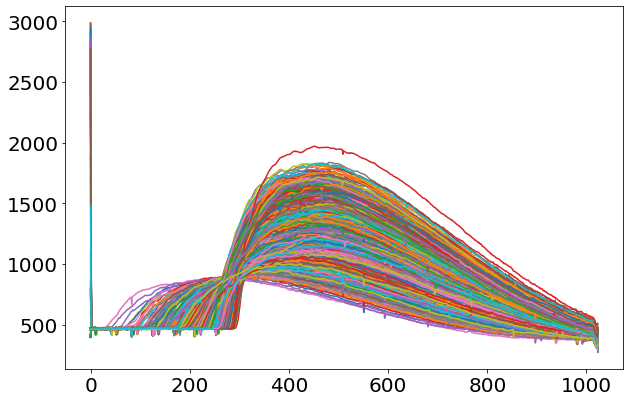

----------------------
SiPM Channel 2 of 16


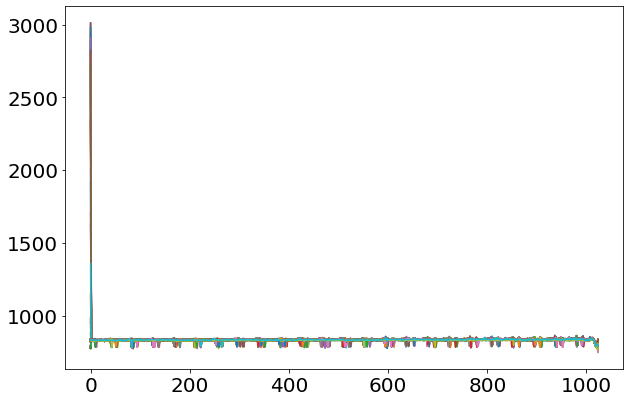

----------------------
SiPM Channel 3 of 16


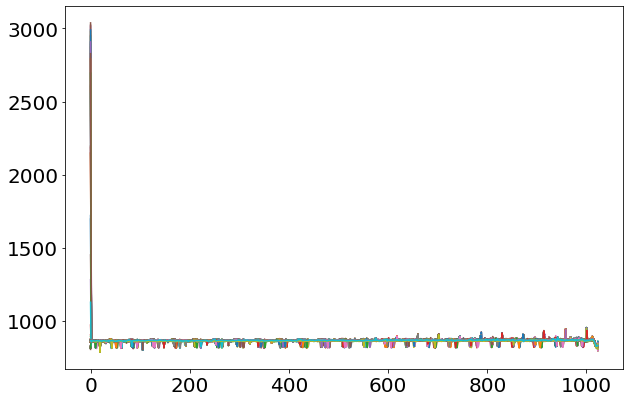

----------------------
SiPM Channel 4 of 16


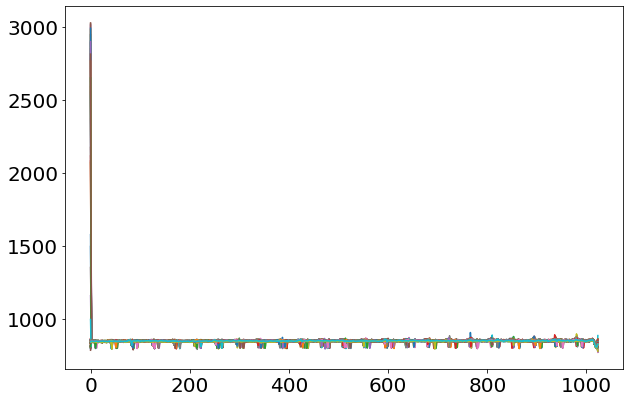

----------------------
SiPM Channel 5 of 16


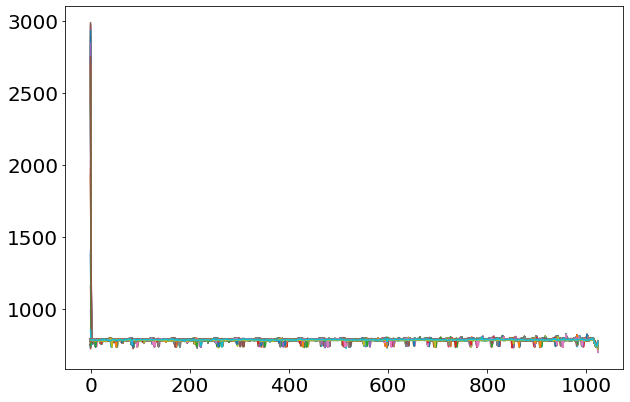

----------------------
SiPM Channel 6 of 16


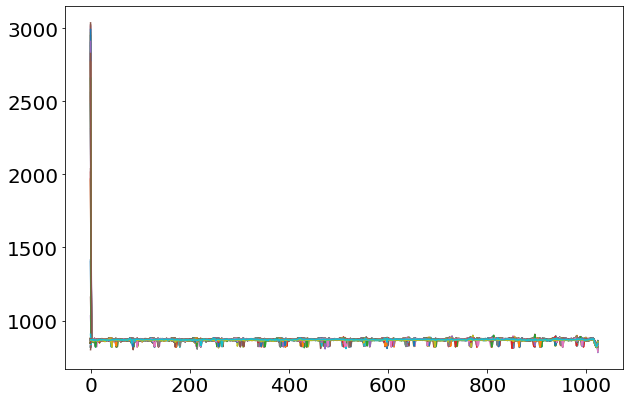

----------------------
SiPM Channel 7 of 16


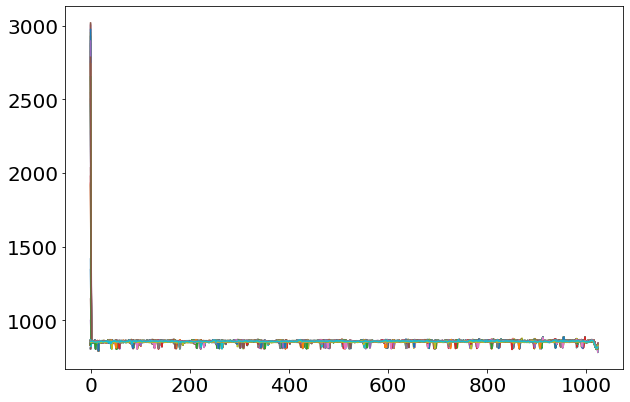

----------------------
SiPM Channel 8 of 16


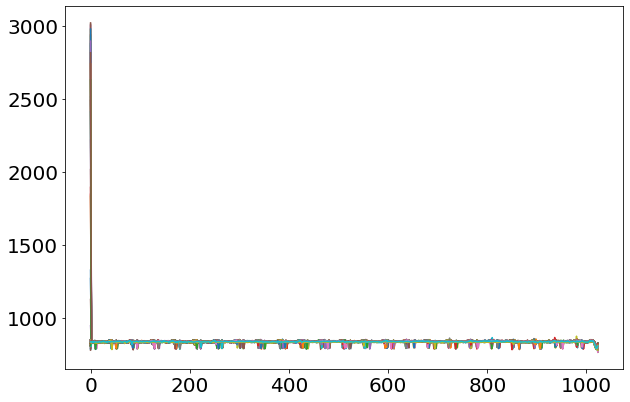

----------------------
SiPM Channel 9 of 16


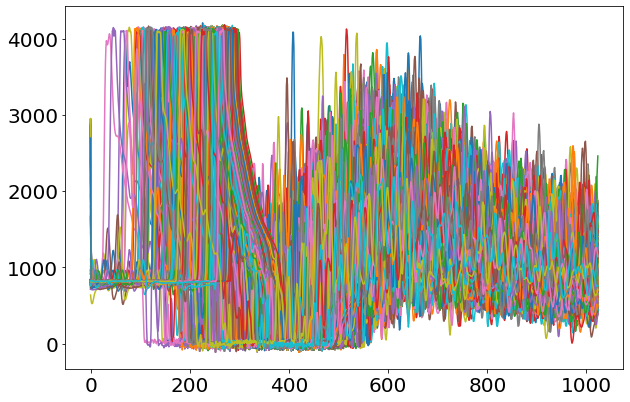

----------------------
SiPM Channel 10 of 16


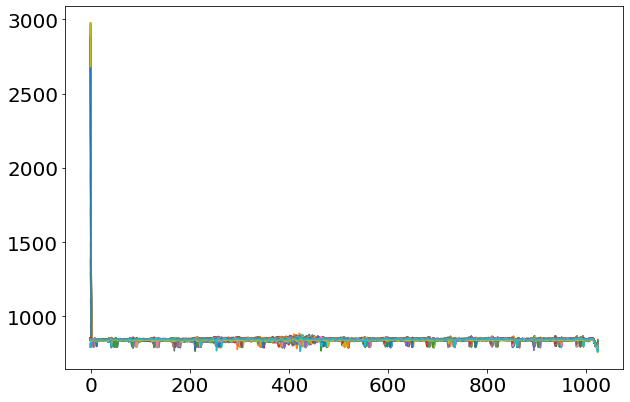

----------------------
SiPM Channel 11 of 16


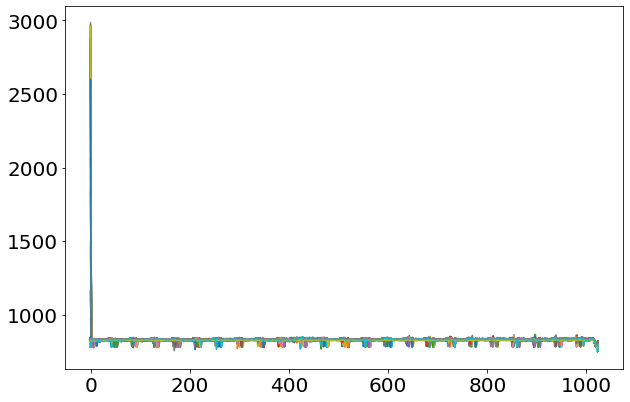

----------------------
SiPM Channel 12 of 16


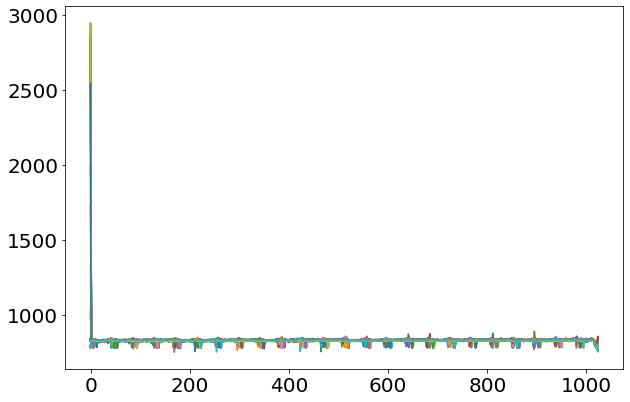

----------------------
SiPM Channel 13 of 16


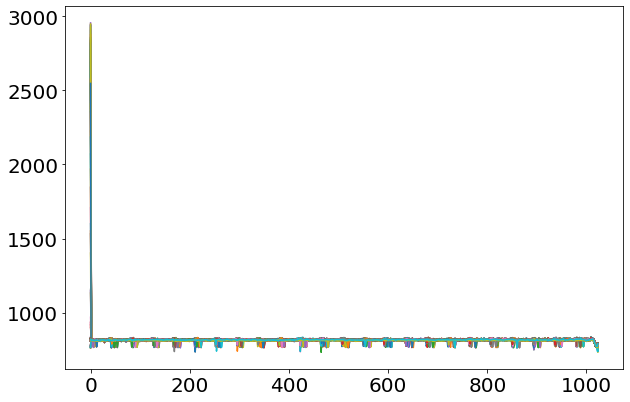

----------------------
SiPM Channel 14 of 16


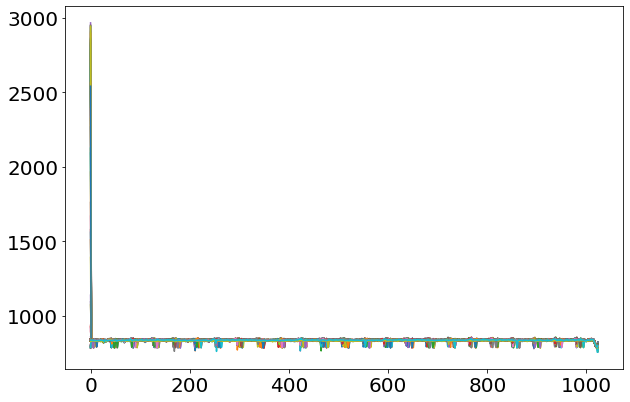

----------------------
SiPM Channel 15 of 16


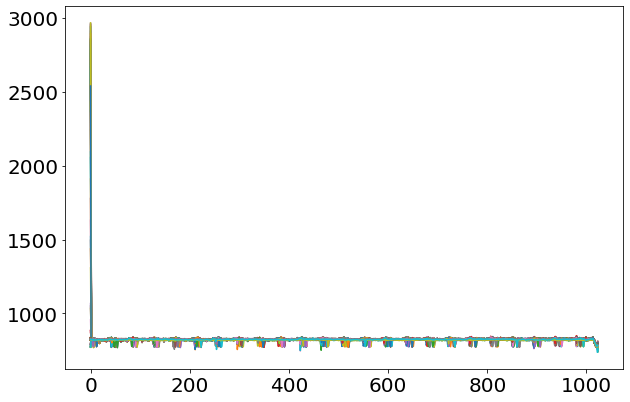

----------------------
SiPM Channel 16 of 16


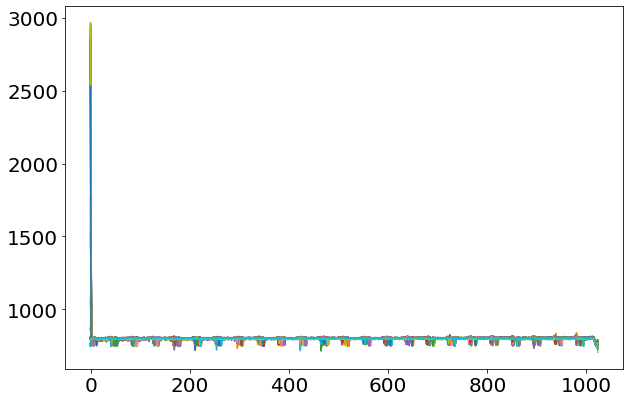

----------------------
SiPM Channel 17 of 16


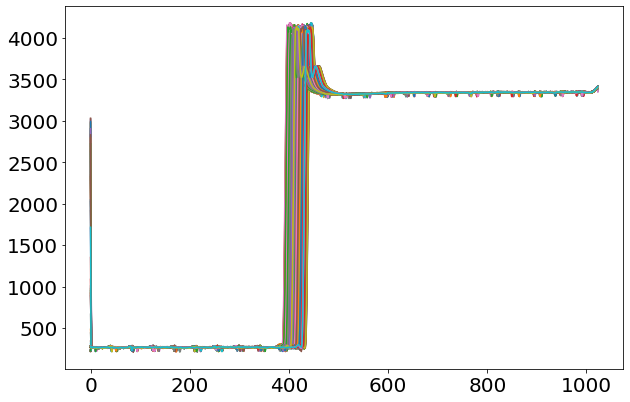

----------------------
hdf5 elapsed time: 3.2s
total elapsed time 171.2s


In [ ]:
# move to position 1
position = "01"
pico.exec("m.move_distance_mm_y(4, speed_fast=True, forward=True)")
pico.exec("m.move_distance_mm_x(4, speed_fast=True, forward=True)")

# acquire and plot
starttime = time.time()
nevents = 1000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
    print(f"SiPM Channel {ich+1} of 16")
    for ev in range (min(1000, nevents)):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
    
t0 = time.time()
hdf5_fnam = f"20260511_hfv2_TAC1p9x19_44p5V_Ref100mV_Sum000mV_100e_pos{position}_CAEN.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.000 mm
Moved ΔM = 1.8844 mm → New Z = 45.430 mm
Steps moved: 2412
m.move_distance_mm_y(4, speed_fast=True, forward=True)
Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.000 mm
Moved ΔM = 1.8844 mm → New Z = 45.430 mm
Steps moved: 2412
>>> 
Moved in x FWD 4.00 mm, M x axis=8.00
m.move_distance_mm_x(4, speed_fast=True, forward=True)
Moved in x FWD 4.00 mm, M x axis=8.00
>>> 
[running] /home/ashmansk/caen/wavedump-3.10.6/src/wavedump --wjatrig 2000
[done]
read 2064000 lines, 2000 events from wave_0.txt
read 2064000 lines, 2000 events from wave_1.txt
read 2064000 lines, 2000 events from wave_2.txt
read 2064000 lines, 2000 events from wave_3.txt
read 2064000 lines, 2000 events from wave_4.txt
read 2064000 lines, 2000 events from wave_5.txt
read 2064000 lines, 2000 events from wave_6.txt
read 2064000 lines, 2000 events from wave_7.txt
read 2064000 lines, 2000 events from wave_8.txt
read 2064000 lines, 2000 events from wave_9.txt
read 2064000 lines, 2

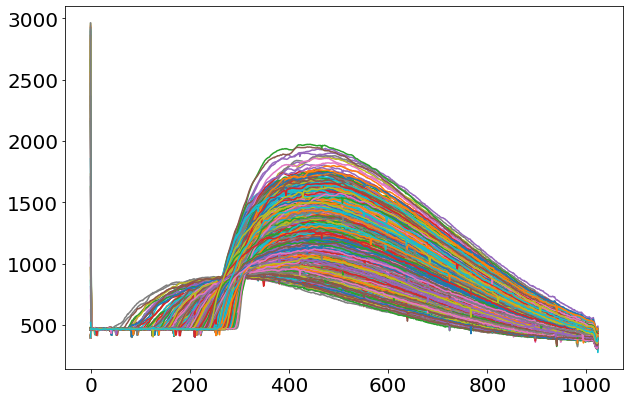

----------------------
SiPM Channel 2 of 16


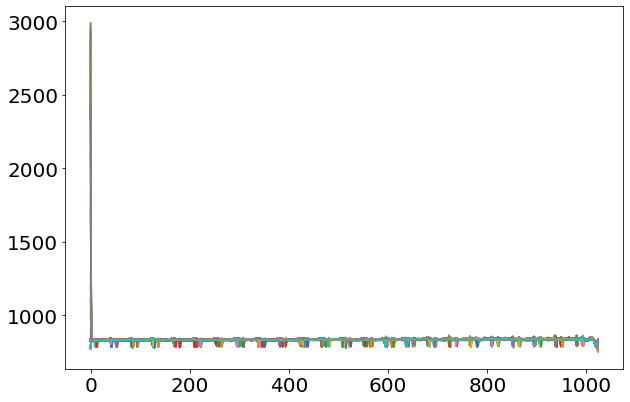

----------------------
SiPM Channel 3 of 16


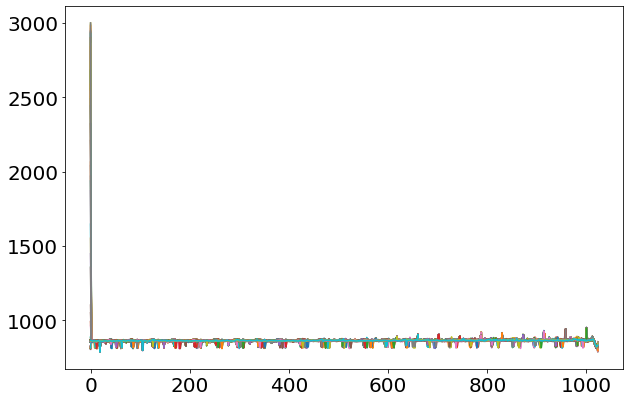

----------------------
SiPM Channel 4 of 16


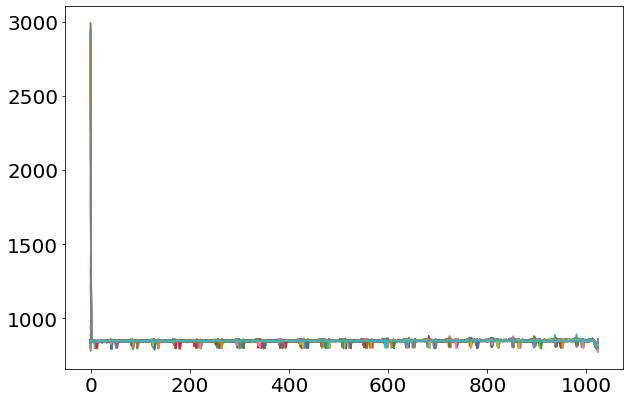

----------------------
SiPM Channel 5 of 16


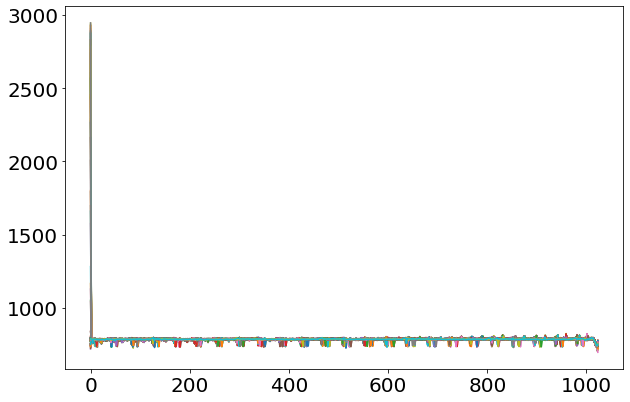

----------------------
SiPM Channel 6 of 16


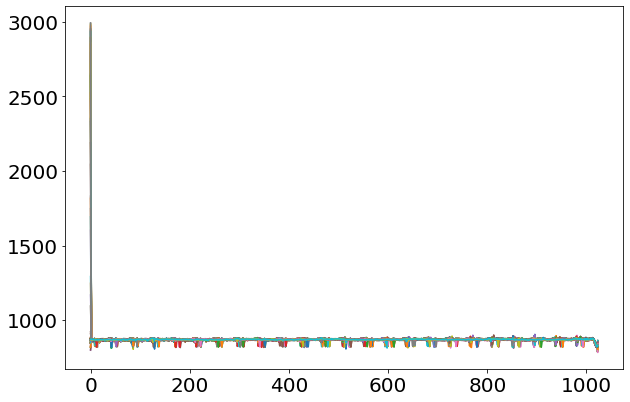

----------------------
SiPM Channel 7 of 16


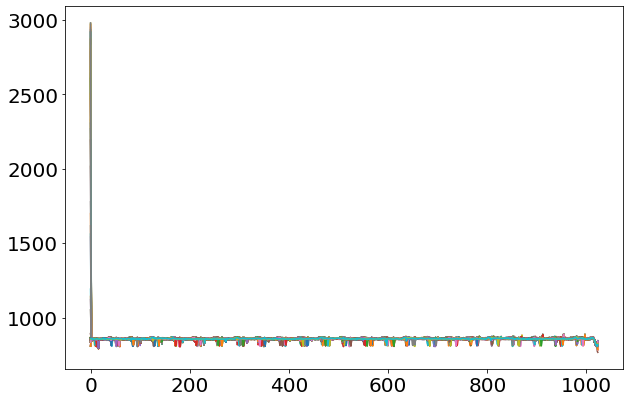

----------------------
SiPM Channel 8 of 16


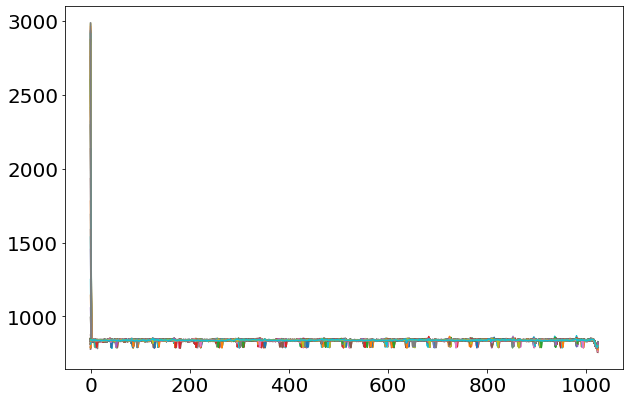

----------------------
SiPM Channel 9 of 16


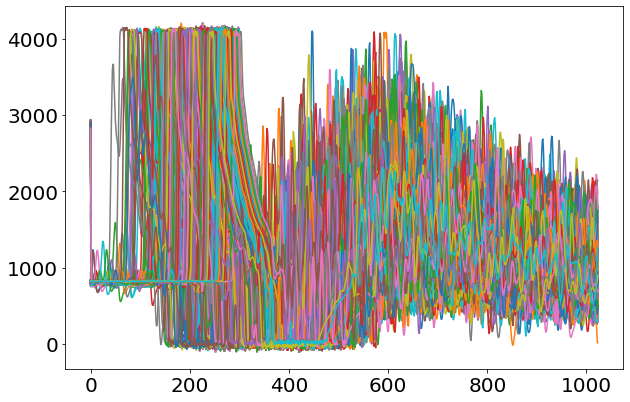

----------------------
SiPM Channel 10 of 16


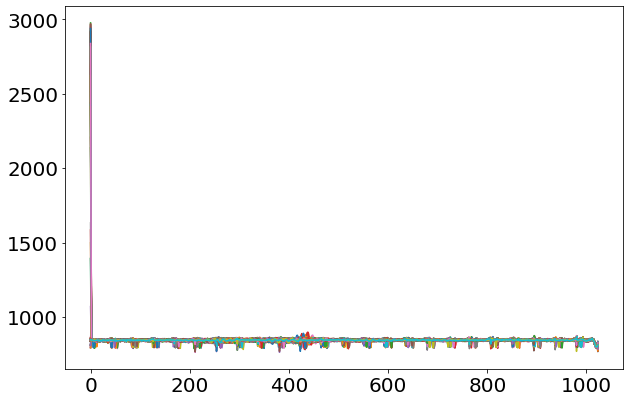

----------------------
SiPM Channel 11 of 16


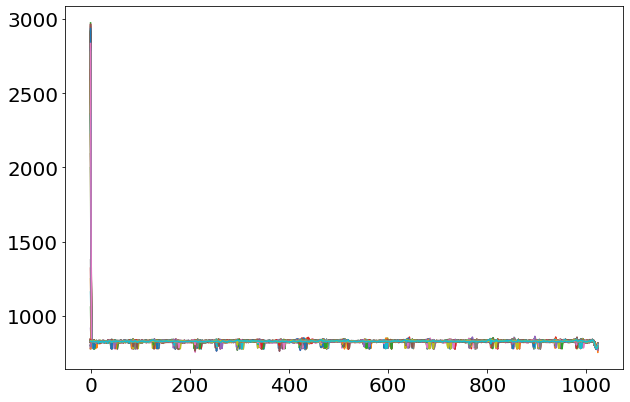

----------------------
SiPM Channel 12 of 16


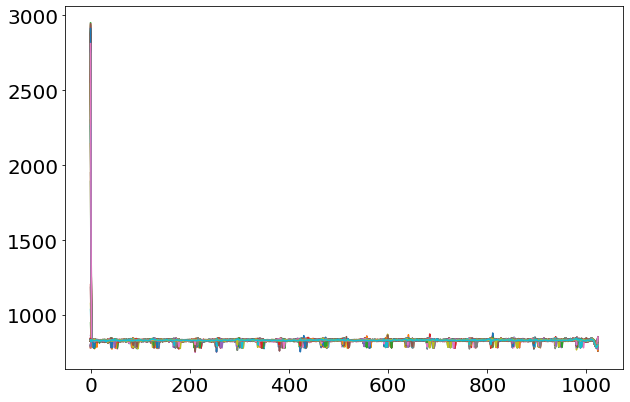

----------------------
SiPM Channel 13 of 16


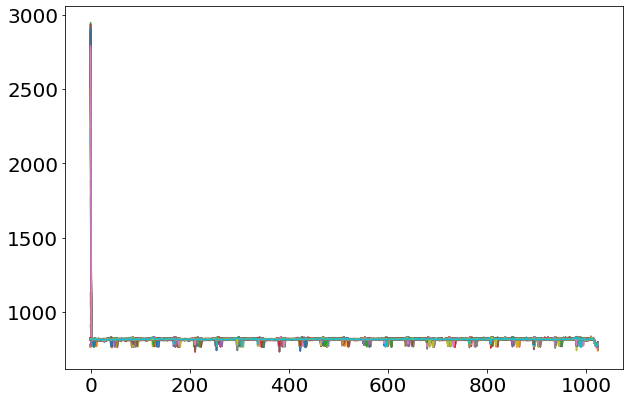

----------------------
SiPM Channel 14 of 16


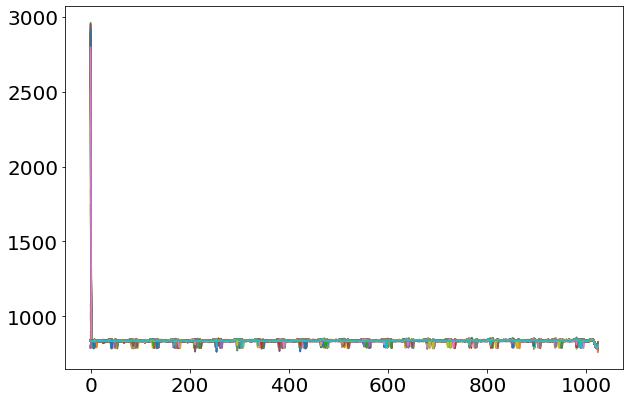

----------------------
SiPM Channel 15 of 16


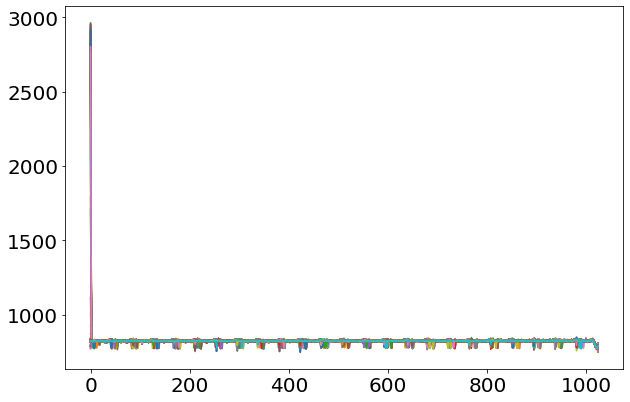

----------------------
SiPM Channel 16 of 16


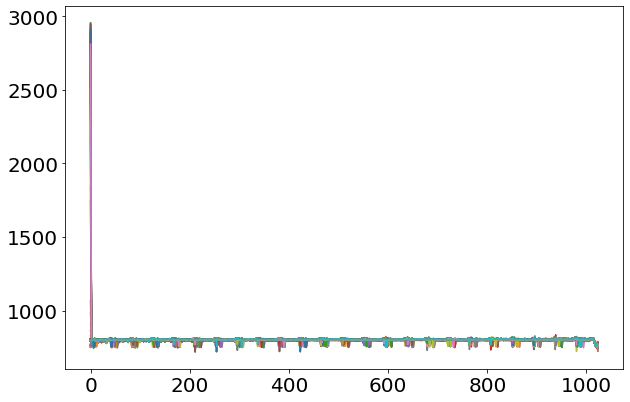

----------------------
SiPM Channel 17 of 16


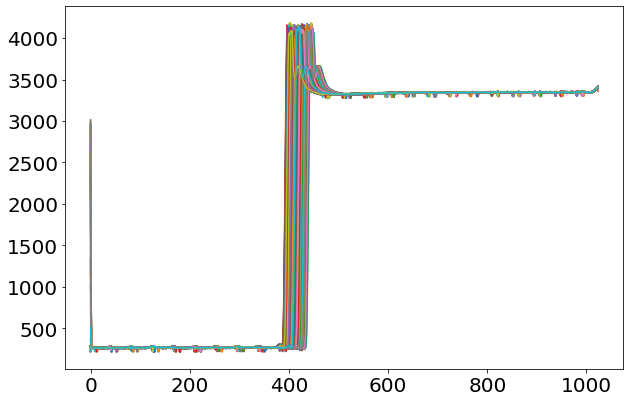

----------------------
hdf5 elapsed time: 6.8s
total elapsed time 301.9s


In [ ]:
# move to position 2
position = "02"
pico.exec("m.move_distance_mm_y(4, speed_fast=True, forward=True)")
pico.exec("m.move_distance_mm_x(4, speed_fast=True, forward=True)")

# acquire and plot
starttime = time.time()
nevents = 2000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
    print(f"SiPM Channel {ich+1} of 16")
    for ev in range (min(1000, nevents)):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
    
t0 = time.time()
hdf5_fnam = f"20260511_hfv2_TAC1p9x19_44p5V_Ref100mV_Sum000mV_100e_pos{position}_CAEN.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.000 mm
Moved ΔM = 2.1039 mm → New Z = 49.430 mm
Steps moved: 2693
m.move_distance_mm_y(4, speed_fast=True, forward=True)
Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.000 mm
Moved ΔM = 2.1039 mm → New Z = 49.430 mm
Steps moved: 2693
>>> 
m.move_distance_mm_x(4, speed_fast=True, forward=True)
Moved in x FWD 4.00 mm, M x axis=12.00
m.move_distance_mm_x(4, speed_fast=True, forward=True)
Moved in x FWD 4.00 mm, M x axis=12.00
>>> 
[running] /home/ashmansk/caen/wavedump-3.10.6/src/wavedump --wjatrig 3000
[done]
read 3096000 lines, 3000 events from wave_0.txt
read 3096000 lines, 3000 events from wave_1.txt
read 3096000 lines, 3000 events from wave_2.txt
read 3096000 lines, 3000 events from wave_3.txt
read 3096000 lines, 3000 events from wave_4.txt
read 3096000 lines, 3000 events from wave_5.txt
read 3096000 lines, 3000 events from wave_6.txt
read 3096000 lines, 3000 events from wave_7.txt
read 3096000 lines, 3000 events from wave_8.txt
read 3096000

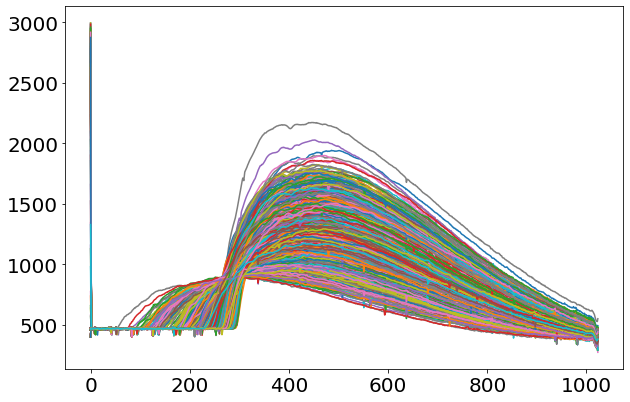

----------------------
SiPM Channel 2 of 16


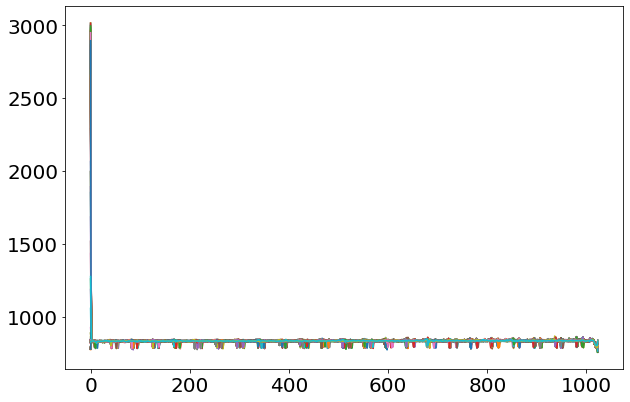

----------------------
SiPM Channel 3 of 16


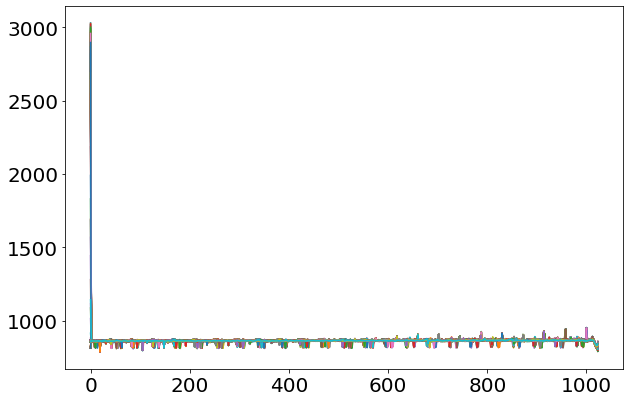

----------------------
SiPM Channel 4 of 16


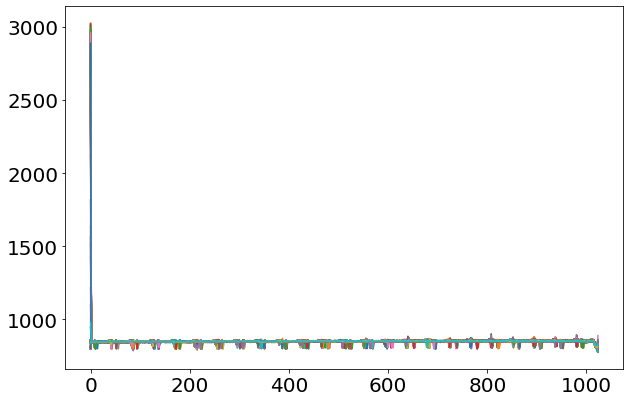

----------------------
SiPM Channel 5 of 16


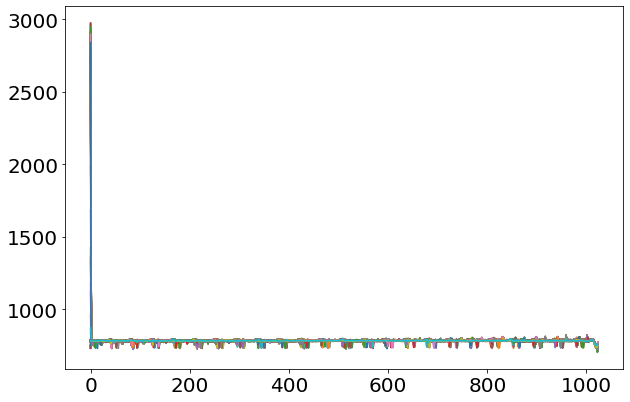

----------------------
SiPM Channel 6 of 16


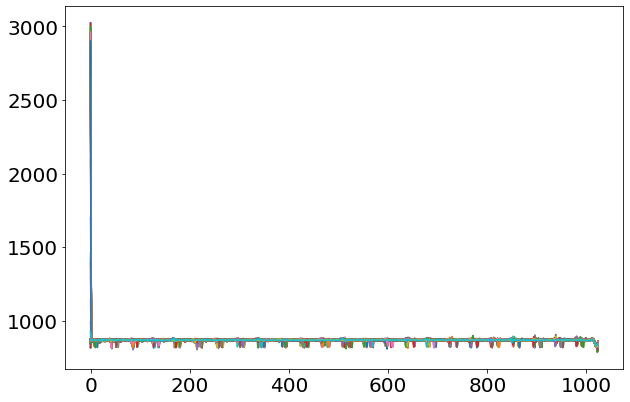

----------------------
SiPM Channel 7 of 16


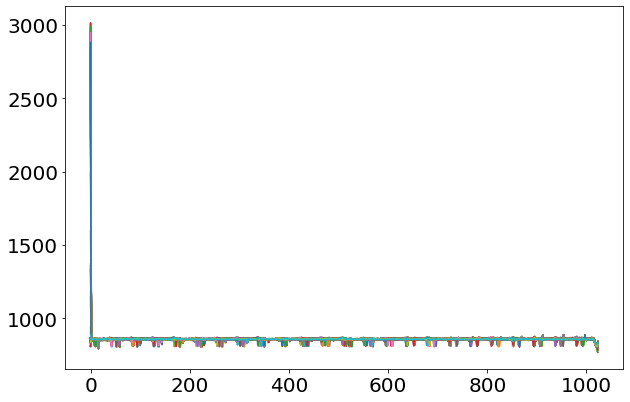

----------------------
SiPM Channel 8 of 16


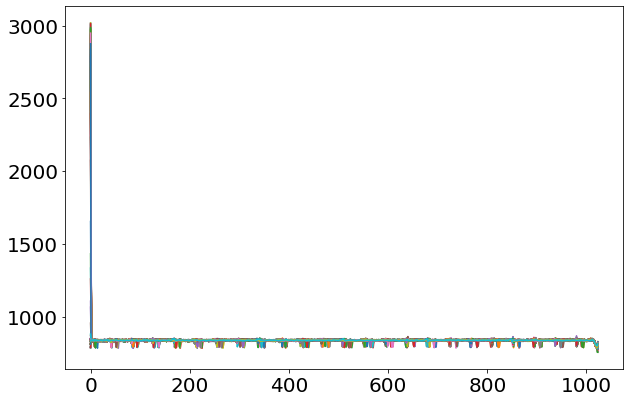

----------------------
SiPM Channel 9 of 16


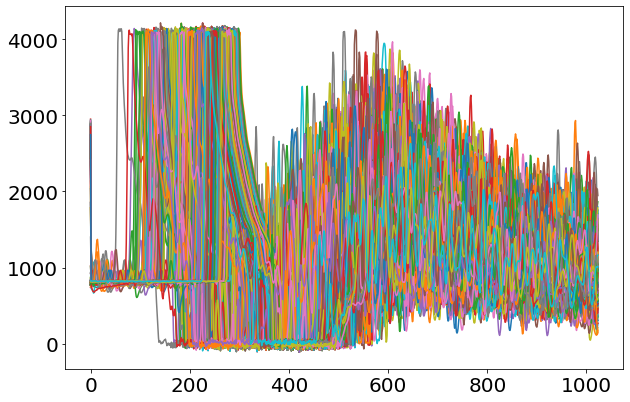

----------------------
SiPM Channel 10 of 16


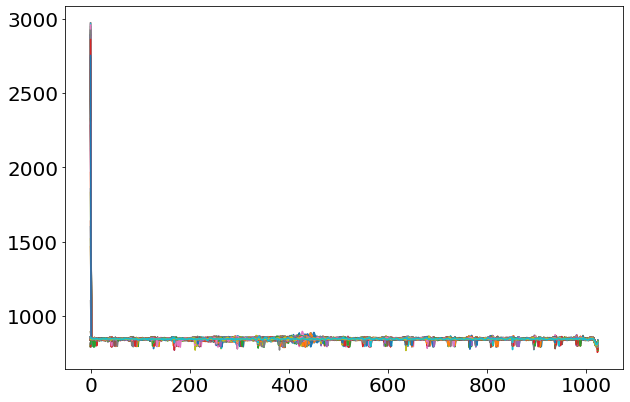

----------------------
SiPM Channel 11 of 16


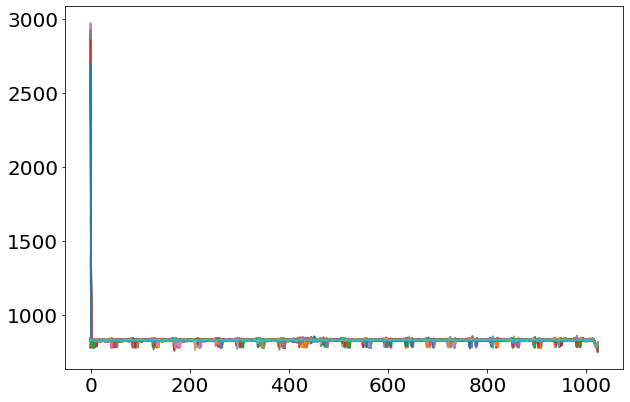

----------------------
SiPM Channel 12 of 16


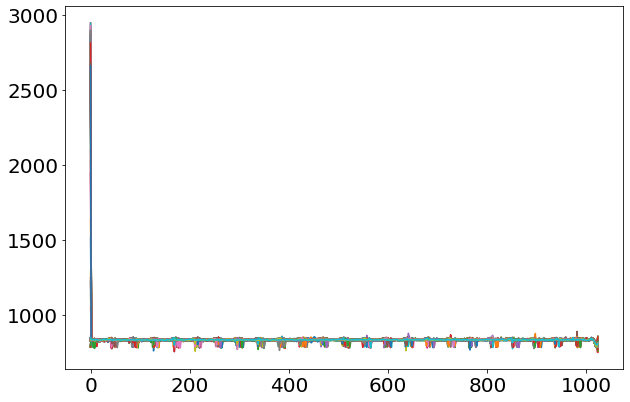

----------------------
SiPM Channel 13 of 16


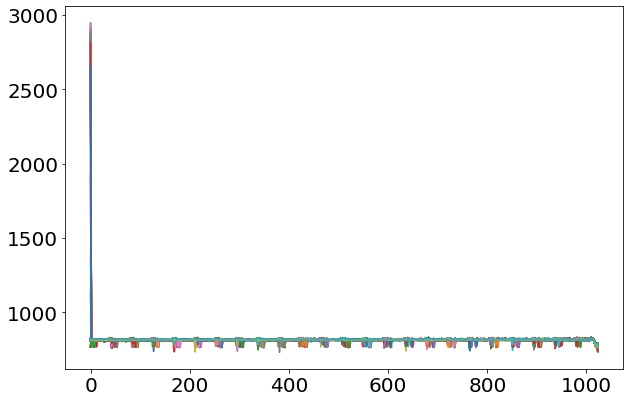

----------------------
SiPM Channel 14 of 16


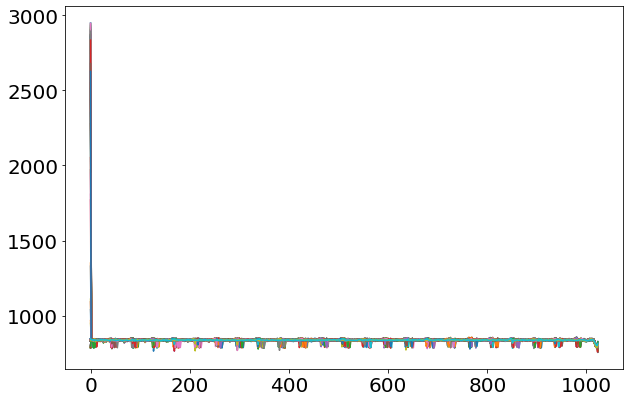

----------------------
SiPM Channel 15 of 16


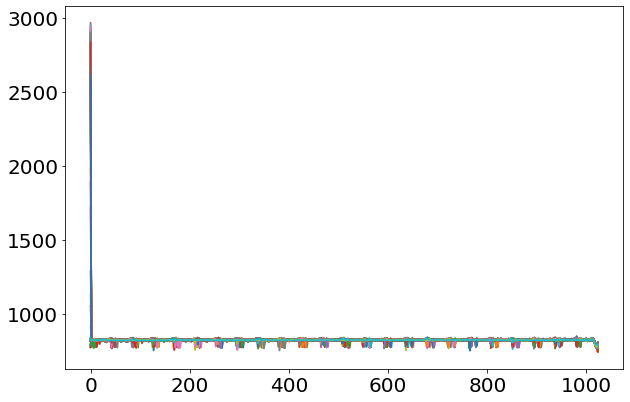

----------------------
SiPM Channel 16 of 16


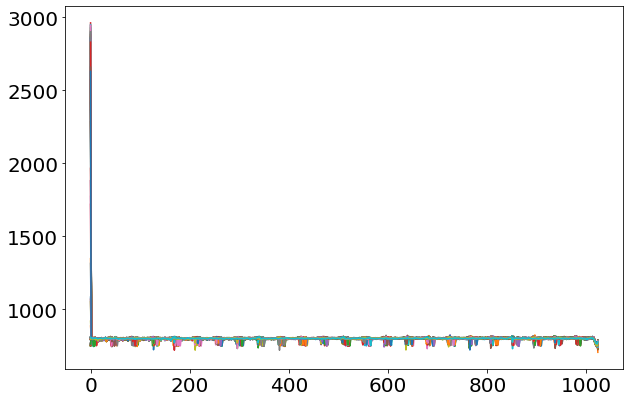

----------------------
SiPM Channel 17 of 16


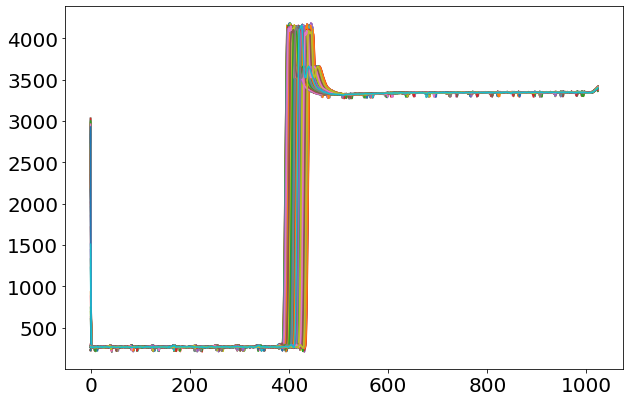

----------------------
hdf5 elapsed time: 11.1s
total elapsed time 444.9s


In [ ]:
# move to position 3
position = "03"
pico.exec("m.move_distance_mm_y(4, speed_fast=True, forward=True)")
pico.exec("m.move_distance_mm_x(4, speed_fast=True, forward=True)")

# acquire and plot
starttime = time.time()
nevents = 3000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
    print(f"SiPM Channel {ich+1} of 16")
    for ev in range (min(1000, nevents)):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
    
t0 = time.time()
hdf5_fnam = f"20260511_hfv2_TAC1p9x19_44p5V_Ref100mV_Sum000mV_100e_pos{position}_CAEN.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.001 mm
Moved ΔM = 2.3391 mm → New Z = 53.431 mm
Steps moved: 2994
m.move_distance_mm_y(4, speed_fast=True, forward=True)
Requested ΔZ = 4.000 mm FWD
Actual ΔZ    = 4.001 mm
Moved ΔM = 2.3391 mm → New Z = 53.431 mm
Steps moved: 2994
>>> 
m.move_distance_mm_x(4, speed_fast=True, forward=True)
Moved in x FWD 4.00 mm, M x axis=16.00
m.move_distance_mm_x(4, speed_fast=True, forward=True)
Moved in x FWD 4.00 mm, M x axis=16.00
>>> 
[running] /home/ashmansk/caen/wavedump-3.10.6/src/wavedump --wjatrig 4000
[done]
read 4128000 lines, 4000 events from wave_0.txt
read 4128000 lines, 4000 events from wave_1.txt
read 4128000 lines, 4000 events from wave_2.txt
read 4128000 lines, 4000 events from wave_3.txt
read 4128000 lines, 4000 events from wave_4.txt
read 4128000 lines, 4000 events from wave_5.txt
read 4128000 lines, 4000 events from wave_6.txt
read 4128000 lines, 4000 events from wave_7.txt
read 4128000 lines, 4000 events from wave_8.txt
read 4128000

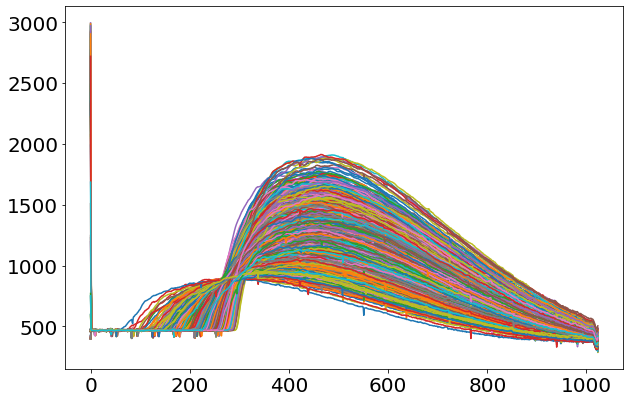

----------------------
SiPM Channel 2 of 16


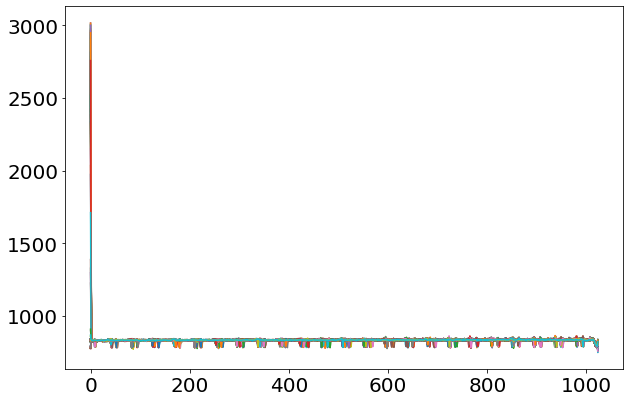

----------------------
SiPM Channel 3 of 16


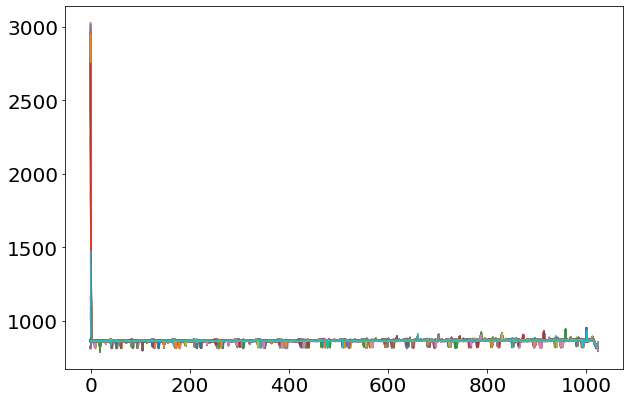

----------------------
SiPM Channel 4 of 16


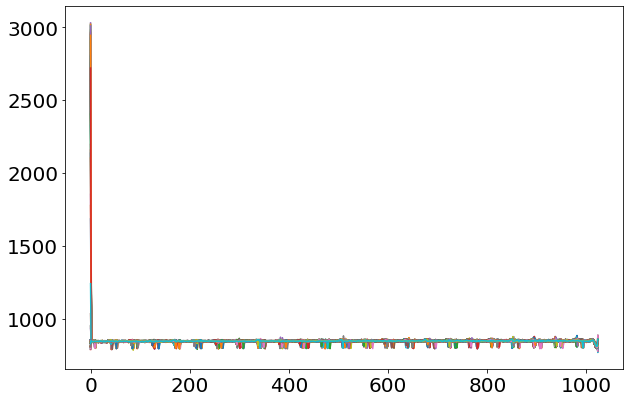

----------------------
SiPM Channel 5 of 16


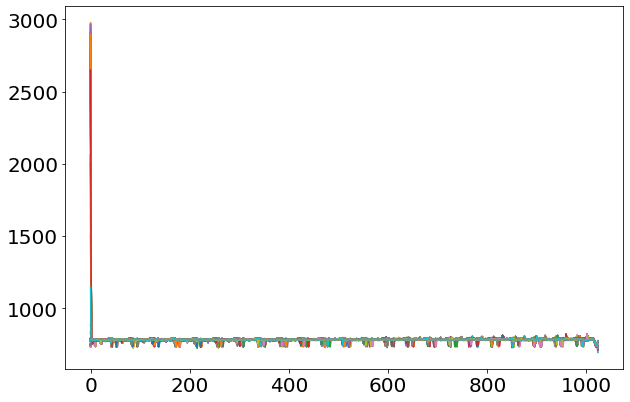

----------------------
SiPM Channel 6 of 16


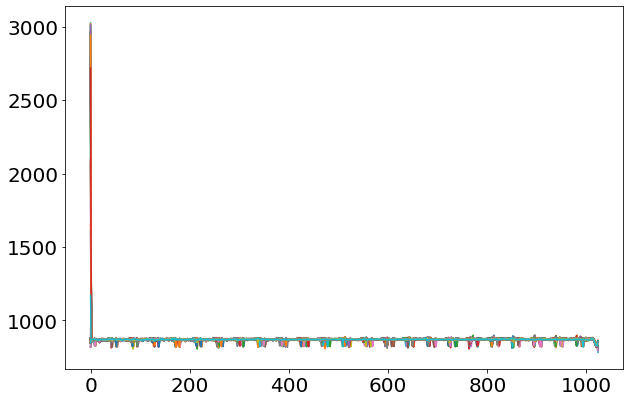

----------------------
SiPM Channel 7 of 16


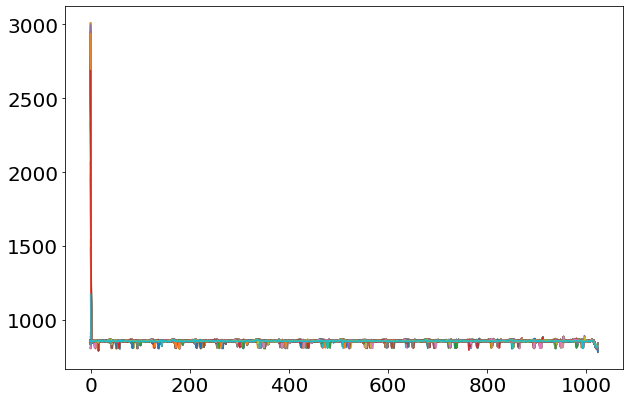

----------------------
SiPM Channel 8 of 16


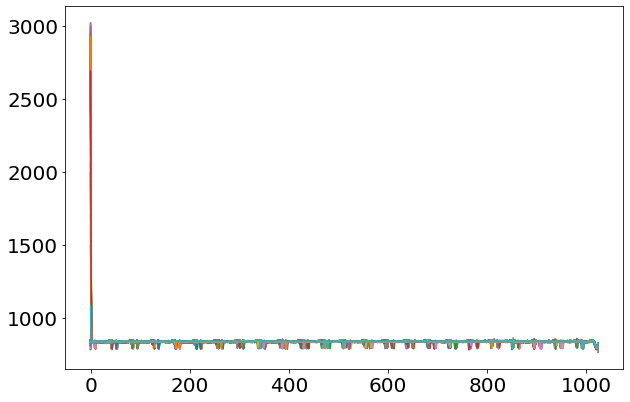

----------------------
SiPM Channel 9 of 16


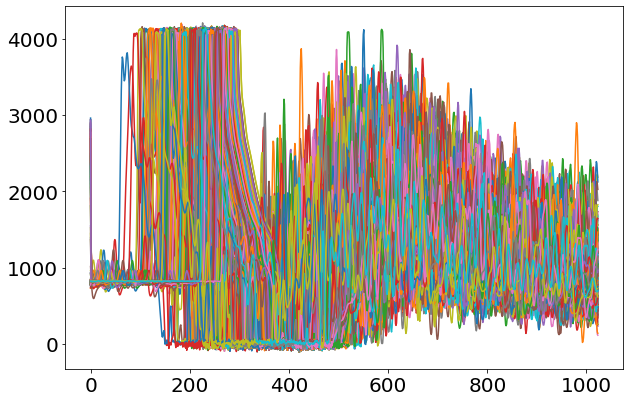

----------------------
SiPM Channel 10 of 16


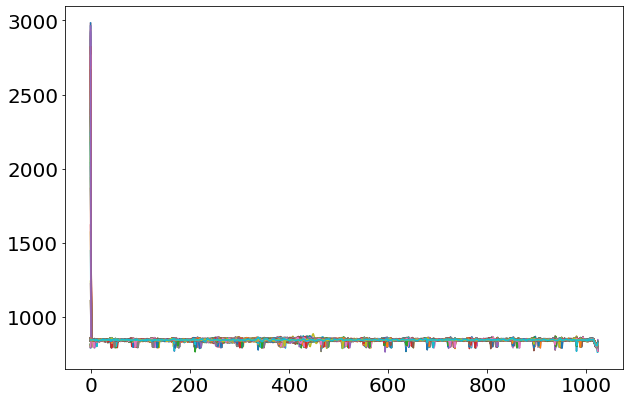

----------------------
SiPM Channel 11 of 16


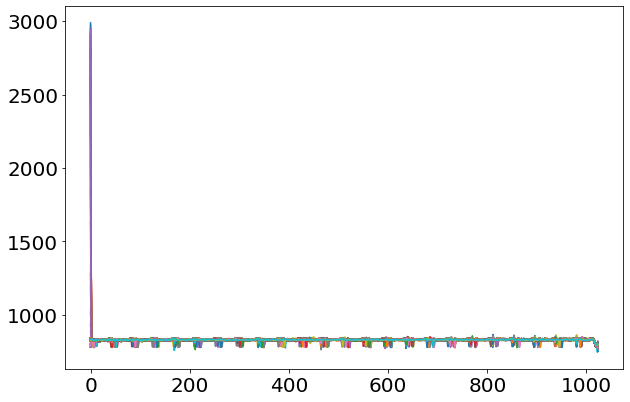

----------------------
SiPM Channel 12 of 16


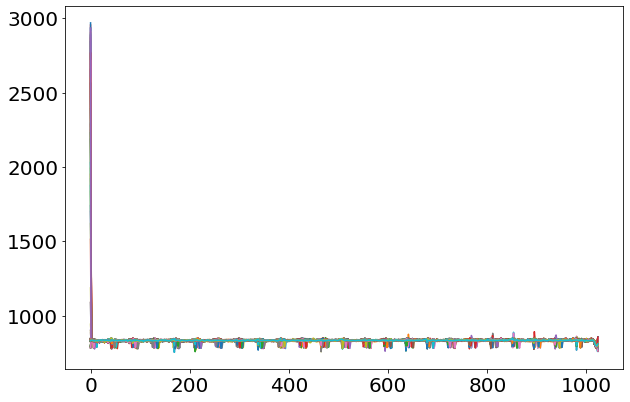

----------------------
SiPM Channel 13 of 16


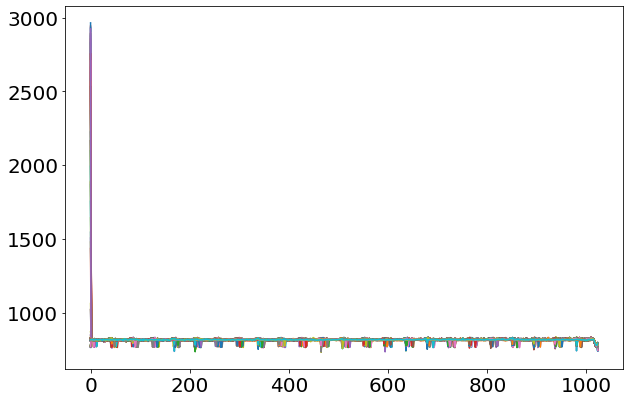

----------------------
SiPM Channel 14 of 16


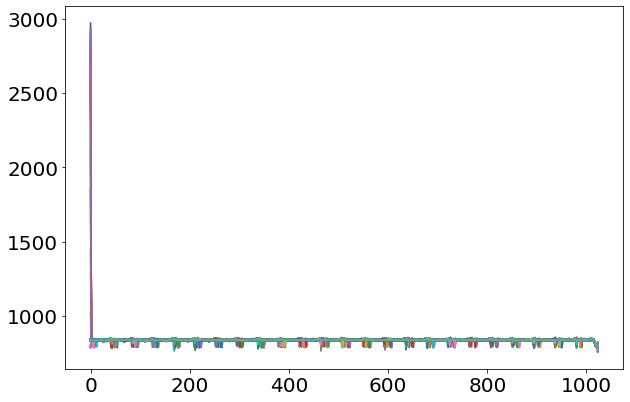

----------------------
SiPM Channel 15 of 16


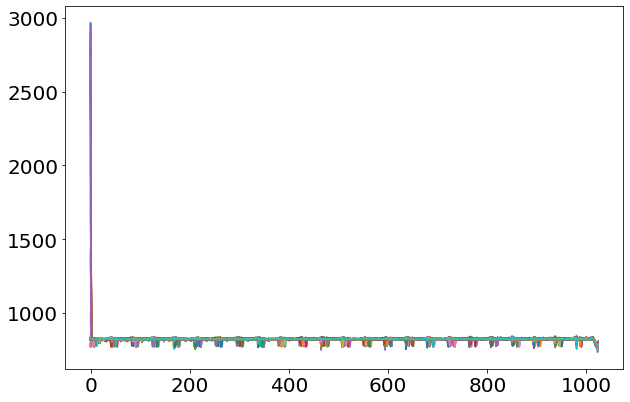

----------------------
SiPM Channel 16 of 16


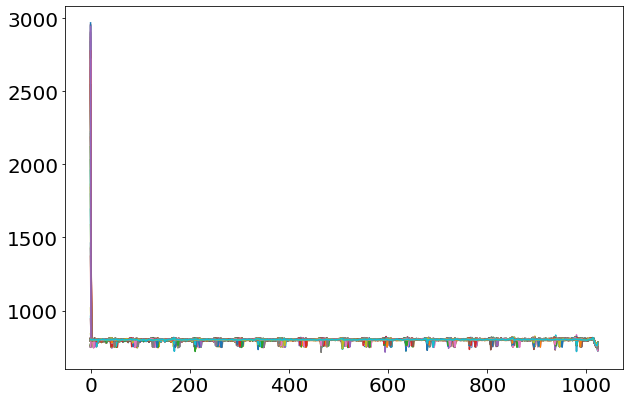

----------------------
SiPM Channel 17 of 16


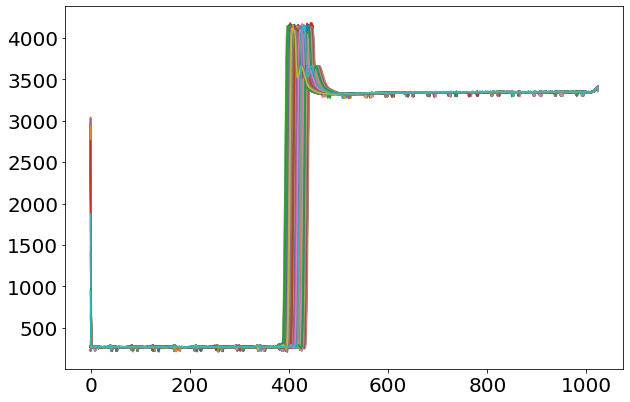

----------------------
hdf5 elapsed time: 14.6s
total elapsed time 574.6s


In [ ]:
# move to position 4
position = "04"
pico.exec("m.move_distance_mm_y(4, speed_fast=True, forward=True)")
pico.exec("m.move_distance_mm_x(4, speed_fast=True, forward=True)")

# acquire and plot
starttime = time.time()
nevents = 4000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
    print(f"SiPM Channel {ich+1} of 16")
    for ev in range (min(1000, nevents)):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
    
t0 = time.time()
hdf5_fnam = f"20260511_hfv2_TAC1p9x19_44p5V_Ref100mV_Sum000mV_100e_pos{position}_CAEN.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
pico.exec("m.move_distance_mm_y(16, speed_fast=True, forward=False)")
pico.exec("m.move_distance_mm_x(16, speed_fast=True, forward=False)")

m.move_distance_mm_y(16, speed_fast=True, forward=False)
Requested ΔZ = 16.000 mm REV
Actual ΔZ    = -15.999 mm
Moved ΔM = -8.0055 mm → New Z = 37.431 mm
Steps moved: 10247
m.move_distance_mm_y(16, speed_fast=True, forward=False)
Requested ΔZ = 16.000 mm REV
Actual ΔZ    = -15.999 mm
Moved ΔM = -8.0055 mm → New Z = 37.431 mm
Steps moved: 10247
>>> 
m.move_distance_mm_x(16, speed_fast=True, forward=False)
Moved in x REV 16.00 mm, M x axis=0.00
m.move_distance_mm_x(16, speed_fast=True, forward=False)
Moved in x REV 16.00 mm, M x axis=0.00
>>> 


In [ ]:
print(pico.exec("m.move_distance_mm_y(4, speed_fast=True, forward=True)"))
print(pico.exec("m.move_distance_mm_x(4, speed_fast=True, forward=False)"))

In [ ]:
print(pico.exec("m.move_distance_mm_x(4, speed_fast=True, forward=False)"))

In [ ]:
starttime = time.time()
nevents = 100
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

for ich in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
    print(f"SiPM Channel {ich+1} of 16")
    for ev in range (min(1000, nevents)):
        plt.plot(f.trigev[ev].drsu[ich])
    plt.show()
    print(f"----------------------")
    
t0 = time.time()
hdf5_fnam = "20260527_hfv2_TAC1p9x19_44p5V_Ref100mV_Sum000mV_100e_single_CAEN.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum400mV_DB1_midleft3x2_10ke_coinc_CAEN_offset1mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")


In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum420mV_DB1_midleft3x2_10ke_coinc_CAEN_offset2mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum410mV_DB1_midleft3x2_10ke_coinc_CAEN_offset3mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20260123_nuvmtarray_TAC1p9x19_47p5V_Ref280mV_Sum400mV_DB1_midleft3x2_10ke_coinc_CAEN_offset4mm.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 10000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run06.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run07.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run08.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run09.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run10.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run11.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run12.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run13.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run14.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run15.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run16.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
starttime = time.time()
nevents = 15000
t0 = time.time()
f.do_triggered_readout(nevents)
print(list(f.trigev[0].__dict__.keys()))
print(f"acquisition elapsed time {time.time()-t0:.1f}s")
print(f"rough rate = {nevents/(time.time()-t0):.1f}Hz")
beep(1)
t0 = time.time()
f.correct_triggered_readout()
print(f"corrections elapsed time {time.time()-t0:.1f}s")
beep(1)

t0 = time.time()
hdf5_fnam = "20250625_nuvmtarray_4x4xtal_47p5V_Ref250mV_Sum400mV_DB1_midleft3x2_15ke_coinc_CAEN_run17.hdf5"

ns = SimpleNamespace()
ns.drsraw = np.array([e.drsraw for e in f.trigev], dtype=np.int16)
ns.drs = np.array([e.drsgc for e in f.trigev], dtype=np.float32)
ns.drsu = np.array([e.drsu for e in f.trigev], dtype=np.float32)
ns.traw = np.array([e.traw for e in f.trigev], dtype=np.float32)
ns.tcor = np.array([e.tcor for e in f.trigev], dtype=np.float32)
ns.drs_trig_cell = np.array([e.drs_trig_cell for e in f.trigev], dtype=np.int16)
ns.drs_tstamp = np.array([e.tstamp for e in f.trigev], dtype=np.int64)
ns.drs_cellgains = np.array([tc.cellgain for tc in f.tcal], dtype=np.float32)
ns.drs_cellwidth = np.array([tc.celldt for tc in f.tcal], dtype=np.float32)
ns.drs_peds = np.array([tc.cellpeds for tc in f.tcal], dtype=np.float32)
ns.drs_wiggle_shape = np.array([tc.wiggleshape for tc in f.tcal], dtype=np.float32)
ns.drs_mean_shape = np.array([tc.meanshape for tc in f.tcal], dtype=np.float32)

if "hf" in vars():
    hf.close()
    del hf

hf = h5py.File(hdf5_fnam, "w")

def cds(dsetname, comment):
    ds = hf.create_dataset(
        dsetname, 
        data=ns.__dict__[dsetname],
        shuffle=True,
        compression="gzip",
        compression_opts=1)
    ds.attrs["comment"] = comment

cds("drsraw", "raw uncorrected DRS samples [event][channel][sample]")
cds("drs", "DRS samples with pedestal and gain corrections applied")
cds("drsu", "DRS corrected samples, resampled to equal time intervals")
cds("traw", "nominal uncorrected DRS sample times")
cds("tcor", "DRS sample times, corrected via timing calibration")
cds("drs_trig_cell", "DRS trigger/stop cell ID [event][channel]")
cds("drs_tstamp", "CAEN board time stamp [event]")
cds("drs_cellgains", "voltage gain [channel][cell] from DRS calibration")
cds("drs_cellwidth", "cell width (ns) [channel][cell] from DRS timing calibration")
cds("drs_peds", "DRS pedestal [channel][cell] from DRS calibration")
cds("drs_wiggle_shape", "fitted 'wiggle' shape subtracted from each DRS waveform")
cds("drs_mean_shape", "mean waveform, in absence of signal, CAEN board artifact")
hf.close()
del hf
print(f"hdf5 elapsed time: {time.time()-t0:.1f}s")
print(f"total elapsed time {time.time()-starttime:.1f}s")

In [ ]:
beep(2)

In [ ]:
run export_to_html --timestamp